In [16]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import datetime as dt 
import matplotlib.dates as mdates

DATABASE_FILE_1H="../data/20260512153600__stream_retina__1h.db"
DATABASE_FILE_6H="../data/20260508145844__stream_retina__6h.db"
DATABASE_FILE_24H="../data/20260512102024__stream_retina__24h.db"

In [3]:
con1h = sqlite3.connect(DATABASE_FILE_1H)
con6h = sqlite3.connect(DATABASE_FILE_6H)
con24h = sqlite3.connect(DATABASE_FILE_24H)

In [14]:
display(Markdown(f"""
# Retina Production Server FIE Stream Meta Analysis on 1 hour, 6 hours, and 24 hours Data

| Field                  | Value |
| ---------------------- | ----- |
| Author                 | Ufuk Bombar |
| Notebook Creation Date | 2026-05-14 |
| Notebook Running Time  | {dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")} |
| Database Files         | `{DATABASE_FILE_1H}` |
|                        | `{DATABASE_FILE_6H}` |
|                        | `{DATABASE_FILE_24H}` |

## Motivation

This notebook investigates how the FIE stream evolves as the streaming horizon is extended
from 1 hour to 6 hours to 24 hours. Concretely, we ask: does a longer streaming window
reveal more FDHs, stabilize forwarding decision observations, or simply accumulate
redundant data? Understanding this trade-off is important for calibrating the right streaming
duration in production deployments of Retina, and for assessing whether the system's
FDH coverage and refresh cadence behave as expected over longer time scales.

## Research Questions

TBD

## Prerequisites

- To understand the concepts used in this notebook (FDH, PD, FIE, etc.), refer to the
  accompanying draft: *Moving Retina to Forwarding Decision Handle-Centered Probing* (Friedman, 2026).
- The forwarding score metric used in this notebook is introduced in the following paper:
  Bombar, U., Vermeulen, K., Fourmaux, O., and Friedman, T. *Forwarding Score: A New Metric
  for Assessing the Quality of Internet Route Surveys*. Poster at IMC '25: Proceedings of the
  2025 ACM Internet Measurement Conference. https://dl.acm.org/doi/10.1145/3730567.3768596
- To run this notebook, an SQLite database file containing the streamed FIE data must be
  present in the working directory.

## Methodology

Please refer to the notebooks for understanding the methodology used.

Different from the 1 hour and 6 hours, the 24 hours data streaming took place in the iprs2 
machine (previously known as the dev machine in Sorbonne), where it was expected to have 
slower network connection.

Addiitonally, the streamed data only consists of complete FIEs (both the near and far reply
addresses are non-nil).
"""))


# Retina Production Server FIE Stream Meta Analysis on 1 hour, 6 hours, and 24 hours Data

| Field                  | Value |
| ---------------------- | ----- |
| Author                 | Ufuk Bombar |
| Notebook Creation Date | 2026-05-14 |
| Notebook Running Time  | 2026-05-14 17:00:00 |
| Database Files         | `../data/20260512153600__stream_retina__1h.db` |
|                        | `../data/20260508145844__stream_retina__6h.db` |
|                        | `../data/20260512102024__stream_retina__24h.db` |

## Motivation

This notebook investigates how the FIE stream evolves as the streaming horizon is extended
from 1 hour to 6 hours to 24 hours. Concretely, we ask: does a longer streaming window
reveal more FDHs, stabilize forwarding decision observations, or simply accumulate
redundant data? Understanding this trade-off is important for calibrating the right streaming
duration in production deployments of Retina, and for assessing whether the system's
FDH coverage and refresh cadence behave as expected over longer time scales.

## Research Questions

TBD

## Prerequisites

- To understand the concepts used in this notebook (FDH, PD, FIE, etc.), refer to the
  accompanying draft: *Moving Retina to Forwarding Decision Handle-Centered Probing* (Friedman, 2026).
- The forwarding score metric used in this notebook is introduced in the following paper:
  Bombar, U., Vermeulen, K., Fourmaux, O., and Friedman, T. *Forwarding Score: A New Metric
  for Assessing the Quality of Internet Route Surveys*. Poster at IMC '25: Proceedings of the
  2025 ACM Internet Measurement Conference. https://dl.acm.org/doi/10.1145/3730567.3768596
- To run this notebook, an SQLite database file containing the streamed FIE data must be
  present in the working directory.

## Methodology

Please refer to the notebooks for understanding the methodology used.

Different from the 1 hour and 6 hours, the 24 hours data streaming took place in the iprs2 
machine (previously known as the dev machine in Sorbonne), where it was expected to have 
slower network connection.

Addiitonally, the streamed data only consists of complete FIEs (both the near and far reply
addresses are non-nil).


## Understanding the Analysisv1 Results

### Dataset analysis

From the dataset metadata the first change is that in the 24 hours streaming there are some missing 
sequence numbers, which means that the streaming was slower that FIE production. This might be caused
by the change in network, or the multiple streamings taking place at the same time, or simply the 
extended stream time finally catching up and filling up the ring buffer.

The skipped sequence numbers corresponds to `1.38%` of the total streamed FIEs which is `13162636`.

To better understand why these skipps occured, we can take a look at how they are distributed by time.


### Skipped Sequence Numbers in 24h Dataset

| Metric | Value |
|---|---|
| Total streamed FIEs | `13,162,636` |
| Total skipped FIEs | `184,111` |
| Skip rate | `1.38%` |
| Number of gap events | `132` |


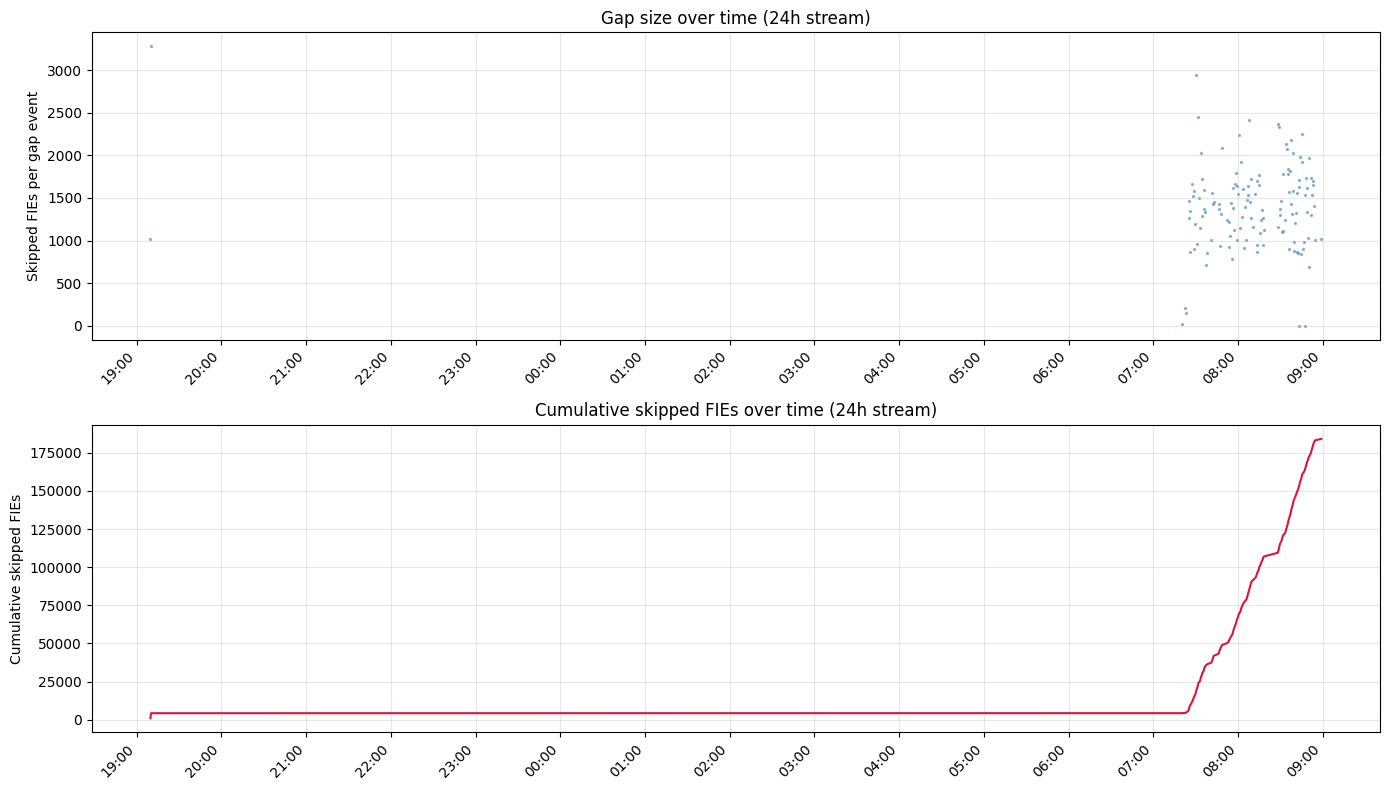

In [17]:
df_24h = pd.read_sql("SELECT sequence_number, production_timestamp FROM fies ORDER BY sequence_number", con24h)
df_24h["production_timestamp"] = pd.to_datetime(df_24h["production_timestamp"])

# Detect gaps in sequence numbers
df_24h["expected"] = df_24h["sequence_number"].shift(1) + 1
df_24h["skipped"] = df_24h["sequence_number"] - df_24h["expected"]
gaps = df_24h[df_24h["skipped"] > 0].copy()

total_streamed = len(df_24h)
total_skipped = int(gaps["skipped"].sum())
skip_rate = total_skipped / (total_streamed + total_skipped) * 100

display(Markdown(f"""
### Skipped Sequence Numbers in 24h Dataset

| Metric | Value |
|---|---|
| Total streamed FIEs | `{total_streamed:,}` |
| Total skipped FIEs | `{total_skipped:,}` |
| Skip rate | `{skip_rate:.2f}%` |
| Number of gap events | `{len(gaps):,}` |
"""))

# Plot skipped sequence numbers over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: gap size over time
axes[0].scatter(gaps["production_timestamp"], gaps["skipped"], s=2, alpha=0.5, color="steelblue")
axes[0].set_ylabel("Skipped FIEs per gap event")
axes[0].set_title("Gap size over time (24h stream)")
axes[0].grid(True, alpha=0.3)

# Bottom: cumulative skipped FIEs over time
gaps_sorted = gaps.sort_values("production_timestamp")
axes[1].plot(gaps_sorted["production_timestamp"], gaps_sorted["skipped"].cumsum(), color="crimson")
axes[1].set_ylabel("Cumulative skipped FIEs")
axes[1].set_title("Cumulative skipped FIEs over time (24h stream)")
axes[1].grid(True, alpha=0.3)

# replace fig.autofmt_xdate() with:
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
plt.tight_layout()
plt.show()

As seen from the cumulative skip plot, the accumulation of skipped FIEs started towards
the end of the stream. This suggests that the ring buffer was slowly filling up throughout
the streaming session, and finally reached capacity near the end, causing FIEs to be
dropped. This is consistent with a steady but sustainable overproduction of FIEs relative
to the streaming throughput — rather than a sudden burst or network incident — which
gradually exhausted the buffer over the course of the 24-hour window.

__Next Steps__: Since this is the case with only the 24 hour data in iprs2 machine, I 
would like to investigate what happens if the network connection is better. Thus another
24 hour streaming experiment is being conducted in my personal laptop with bettwe network
connection.

In [ ]:
#### Question 1: Forwarding Score Disctribution



In [20]:
display(Markdown("""
## Forwarding Score Evolution Over Time (24h Data)

How do the mean, median, min, and max forwarding scores evolve as we extend the
streaming horizon from 1h to 24h in 1-hour slices?
"""))

df_24h_fs = pd.read_sql_query("""
    SELECT near_reply_address, destination_address, near_sent_timestamp
    FROM fies
    WHERE ip_version = 4
""", con24h)

# Filter out IPv6 near addresses and compute /24 prefix
df_24h_fs = df_24h_fs[~df_24h_fs['near_reply_address'].str.contains(':')]
df_24h_fs['prefix24'] = df_24h_fs['destination_address'].apply(
    lambda ip: '.'.join(ip.split('.')[:3]) + '.0'
)
df_24h_fs['near_sent_timestamp'] = pd.to_datetime(df_24h_fs['near_sent_timestamp'], format='ISO8601')

# Compute per-hour slices (cumulative: 1h, 2h, ..., 24h)
t_start = df_24h_fs['near_sent_timestamp'].min()
records = []
for h in range(1, 25):
    cutoff = t_start + pd.Timedelta(hours=h)
    df_slice = df_24h_fs[df_24h_fs['near_sent_timestamp'] < cutoff]
    fs = (
        df_slice
        .groupby('near_reply_address')['prefix24']
        .nunique()
    )
    records.append({
        'hour':        h,
        'mean_fs':     fs.mean(),
        'median_fs':   fs.median(),
        'min_fs':      fs.min(),
        'max_fs':      fs.max(),
        'n_addresses': len(fs),
    })

df_evolution = pd.DataFrame(records)


## Forwarding Score Evolution Over Time (24h Data)

How do the mean, median, min, and max forwarding scores evolve as we extend the
streaming horizon from 1h to 24h in 1-hour slices?


### Summary Table


| Hour | Mean FS | Median FS | Min FS | Max FS | Unique Addresses |
|------|---------|-----------|--------|--------|-----------------|
| 1h | 1.19 | 1 | 1 | 14 | 94,105 |
| 2h | 1.32 | 1 | 1 | 25 | 100,571 |
| 3h | 1.41 | 1 | 1 | 36 | 104,076 |
| 4h | 1.48 | 1 | 1 | 45 | 106,653 |
| 5h | 1.55 | 1 | 1 | 56 | 108,737 |
| 6h | 1.61 | 1 | 1 | 67 | 110,852 |
| 7h | 1.66 | 1 | 1 | 75 | 112,937 |
| 8h | 1.71 | 1 | 1 | 80 | 114,551 |
| 9h | 1.75 | 1 | 1 | 88 | 115,904 |
| 10h | 1.79 | 1 | 1 | 102 | 117,377 |
| 11h | 1.83 | 1 | 1 | 111 | 118,571 |
| 12h | 1.87 | 1 | 1 | 126 | 119,604 |
| 13h | 1.90 | 1 | 1 | 141 | 120,656 |
| 14h | 1.92 | 1 | 1 | 151 | 121,762 |
| 15h | 1.94 | 1 | 1 | 160 | 122,928 |
| 16h | 1.97 | 1 | 1 | 169 | 123,987 |
| 17h | 1.99 | 1 | 1 | 176 | 124,846 |
| 18h | 2.01 | 1 | 1 | 186 | 125,755 |
| 19h | 2.03 | 1 | 1 | 198 | 126,564 |
| 20h | 2.05 | 1 | 1 | 205 | 127,349 |
| 21h | 2.06 | 1 | 1 | 211 | 128,104 |
| 22h | 2.08 | 1 | 1 | 217 | 128,774 |
| 23h | 2.10 | 1 | 1 | 222 | 129,575 |
| 24h | 2.11 | 1 | 1 | 230 | 130,376 |


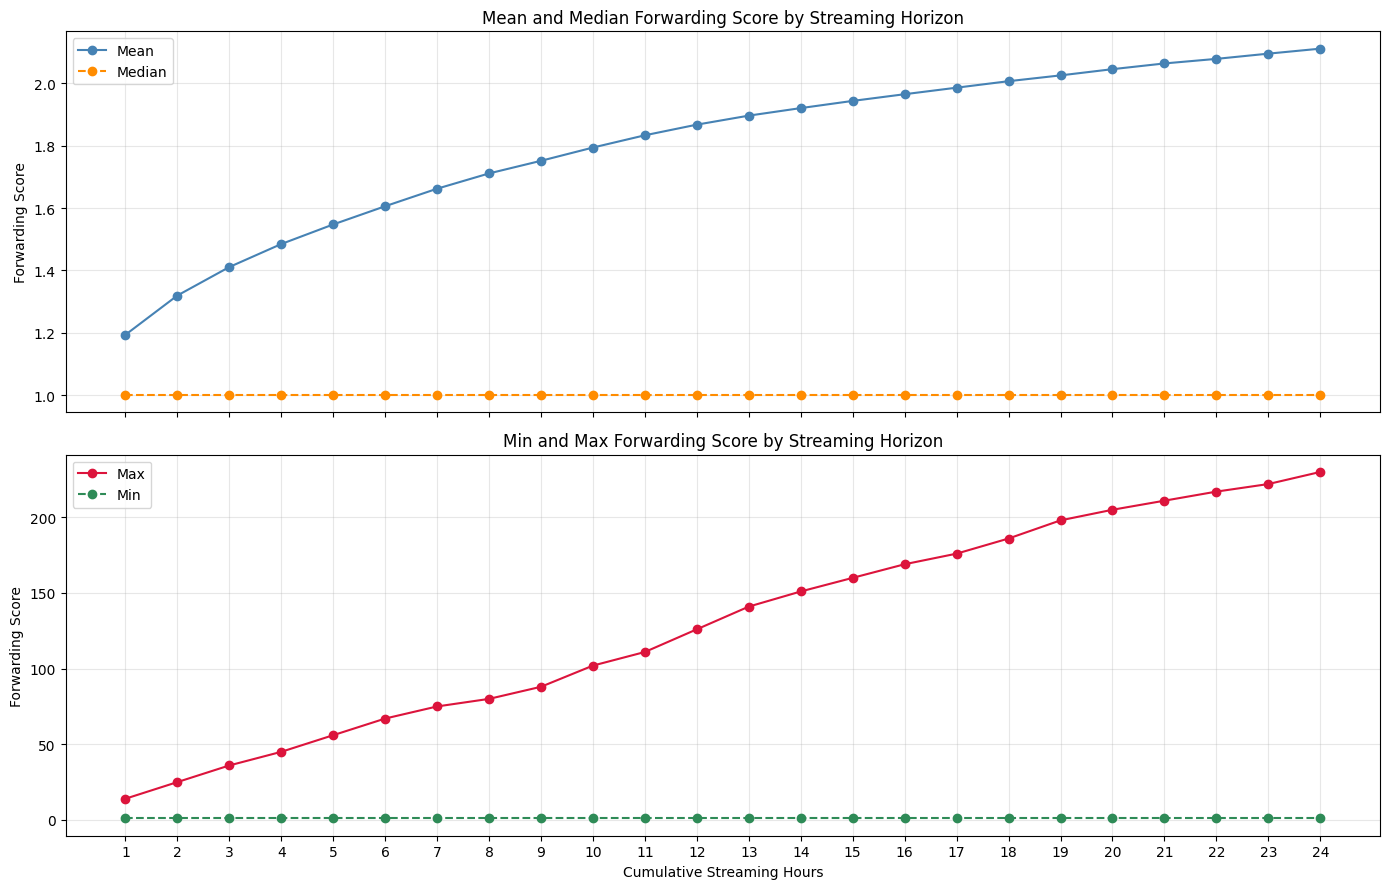

In [21]:
# --- Table ---
display(Markdown("### Summary Table"))
table_rows = "\n".join(
    f"| {int(r.hour)}h | {r.mean_fs:.2f} | {r.median_fs:.0f} | {int(r.min_fs)} | {int(r.max_fs)} | {int(r.n_addresses):,} |"
    for _, r in df_evolution.iterrows()
)
display(Markdown(f"""
| Hour | Mean FS | Median FS | Min FS | Max FS | Unique Addresses |
|------|---------|-----------|--------|--------|-----------------|
{table_rows}
"""))

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: mean and median
axes[0].plot(df_evolution['hour'], df_evolution['mean_fs'],   label='Mean',   marker='o', color='steelblue')
axes[0].plot(df_evolution['hour'], df_evolution['median_fs'], label='Median', marker='o', color='darkorange', linestyle='--')
axes[0].set_ylabel('Forwarding Score')
axes[0].set_title('Mean and Median Forwarding Score by Streaming Horizon')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: min and max
axes[1].plot(df_evolution['hour'], df_evolution['max_fs'], label='Max', marker='o', color='crimson')
axes[1].plot(df_evolution['hour'], df_evolution['min_fs'], label='Min', marker='o', color='seagreen', linestyle='--')
axes[1].set_ylabel('Forwarding Score')
axes[1].set_title('Min and Max Forwarding Score by Streaming Horizon')
axes[1].set_xlabel('Cumulative Streaming Hours')
axes[1].set_xticks(range(1, 25))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
display(Markdown("""
### Observations

The forwarding score distribution evolves slowly but consistently as the streaming horizon
extends. Several patterns stand out:

- **Median and min are stable at 1** throughout the entire 24-hour window. This indicates
  that the majority of observed addresses appear as the near address for only a single /24
  destination prefix, regardless of how long we stream. Most addresses in the dataset are
  lightly observed.

- **Mean grows steadily from 1.19 at 1h to 2.11 at 24h**, but never reaches 3. The growth
  is approximately logarithmic, suggesting diminishing returns: each additional hour of
  streaming contributes less to the average forwarding score than the previous one.

- **Max grows continuously from 14 at 1h to 230 at 24h**, roughly linearly. This means
  that the most broadly observed routers keep accumulating new /24 prefixes throughout
  the stream — there is no saturation for the high-score addresses within 24 hours.

- **Unique addresses grow from ~94k at 1h to ~130k at 24h** (+38%), but the rate of
  discovery slows over time, again consistent with diminishing returns.

Together, these results suggest that extending the streaming horizon primarily benefits
the tail of the distribution — the high-forwarding-score routers that are broadly observed
across the destination space — while the bulk of addresses (median = 1) are already
captured within the first hour.
"""))


### Observations

The forwarding score distribution evolves slowly but consistently as the streaming horizon
extends. Several patterns stand out:

- **Median and min are stable at 1** throughout the entire 24-hour window. This indicates
  that the majority of observed addresses appear as the near address for only a single /24
  destination prefix, regardless of how long we stream. Most addresses in the dataset are
  lightly observed.

- **Mean grows steadily from 1.19 at 1h to 2.11 at 24h**, but never reaches 3. The growth
  is approximately logarithmic, suggesting diminishing returns: each additional hour of
  streaming contributes less to the average forwarding score than the previous one.

- **Max grows continuously from 14 at 1h to 230 at 24h**, roughly linearly. This means
  that the most broadly observed routers keep accumulating new /24 prefixes throughout
  the stream — there is no saturation for the high-score addresses within 24 hours.

- **Unique addresses grow from ~94k at 1h to ~130k at 24h** (+38%), but the rate of
  discovery slows over time, again consistent with diminishing returns.

Together, these results suggest that extending the streaming horizon primarily benefits
the tail of the distribution — the high-forwarding-score routers that are broadly observed
across the destination space — while the bulk of addresses (median = 1) are already
captured within the first hour.



## Question 2: FDH Discovery
A Forwarding Decision Handle (FDH) is defined as a distinct `(near_reply_address, destination_address)` pair,
representing a unique forwarding decision observed in the data. Here we report how many
distinct FDHs the current production deployment of Retina discovers over the observation
period, and characterize the distribution of how many times each FDH is observed.



| Dataset | Total FDHs | Max obs | Median obs | Mean obs | Observed only once |
|---------|-----------|---------|------------|----------|--------------------|
| `1h` | `112,275` | `11` | `6` | `4.87` | `28,183` |
| `6h` | `184,596` | `51` | `6` | `16.61` | `48,386` |
| `24h` | `281,024` | `193` | `6` | `46.84` | `76,666` |


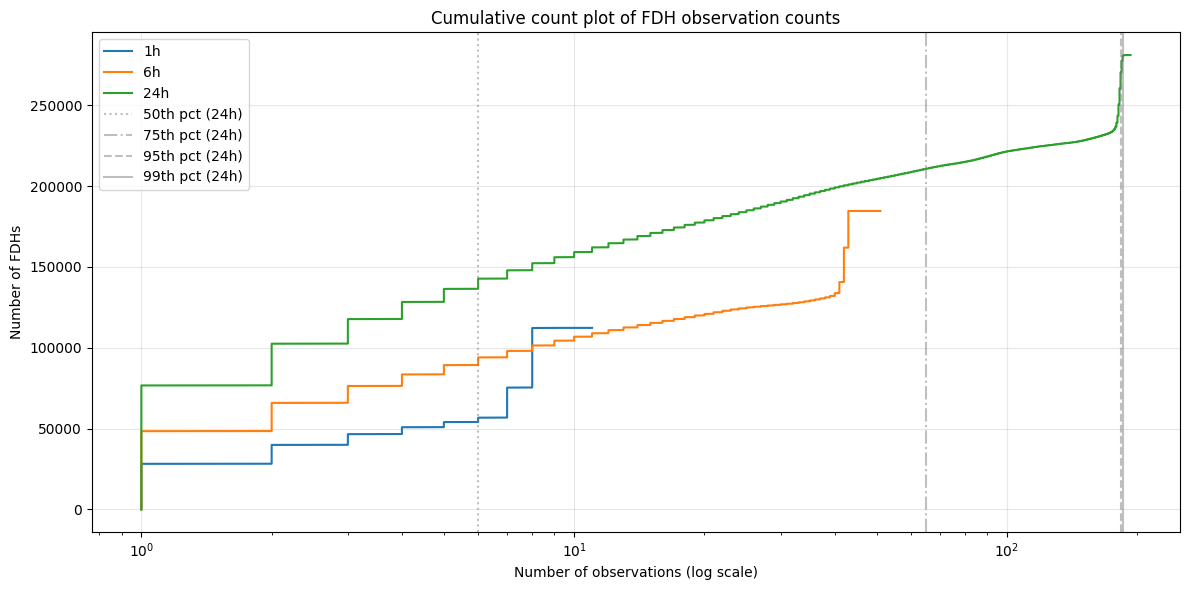

In [25]:
display(Markdown("""
## Question 2: FDH Discovery
A Forwarding Decision Handle (FDH) is defined as a distinct `(near_reply_address, destination_address)` pair,
representing a unique forwarding decision observed in the data. Here we report how many
distinct FDHs the current production deployment of Retina discovers over the observation
period, and characterize the distribution of how many times each FDH is observed.
"""))

datasets = {
    '1h':  con1h,
    '6h':  con6h,
    '24h': con24h,
}

fdh_data = {}
for label, con in datasets.items():
    df_overall = pd.read_sql_query("""
        SELECT near_reply_address, destination_address, COUNT(*) as observations
        FROM fies
        GROUP BY near_reply_address, destination_address
        ORDER BY observations DESC
    """, con)
    fdh_data[label] = df_overall

# --- Summary table ---
rows = "\n".join(
    f"| `{label}` | `{len(d):,}` | `{d['observations'].max()}` "
    f"| `{d['observations'].median():.0f}` "
    f"| `{d['observations'].mean():.2f}` "
    f"| `{(d['observations'] == 1).sum():,}` |"
    for label, d in fdh_data.items()
)
display(Markdown(f"""
| Dataset | Total FDHs | Max obs | Median obs | Mean obs | Observed only once |
|---------|-----------|---------|------------|----------|--------------------|
{rows}
"""))

# --- Plot ---
cmap = plt.get_cmap('tab10')
colors = {'1h': cmap(0), '6h': cmap(1), '24h': cmap(2)}

fig, ax = plt.subplots(figsize=(12, 6))
for label, d in fdh_data.items():
    sorted_obs = d['observations'].sort_values()
    ax.plot(sorted_obs.values, range(len(sorted_obs)),
            label=label, color=colors[label])

for p, ls in zip([50, 75, 95, 99], [':', '-.', '--', '-']):
    ax.axvline(
        fdh_data['24h']['observations'].quantile(p / 100),
        linestyle=ls, color='gray', alpha=0.5, label=f'{p}th pct (24h)'
    )

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of observations (log scale)')
ax.set_ylabel('Number of FDHs')
ax.set_title('Cumulative count plot of FDH observation counts')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
display(Markdown("""
### Observations

The FDH discovery results reveal consistent patterns across all three streaming horizons:

- **Median observations per FDH is stable at 6** across all three datasets. This suggests
  that Retina's refresh cadence reliably probes each discovered FDH roughly 6 times
  regardless of the streaming duration — the per-FDH coverage is consistent by design.

- **Mean observations scale roughly linearly** with the streaming horizon (4.87 → 16.61 → 46.84),
  growing approximately in proportion to the 1h:6h:24h ratio. This is expected: more
  streaming time means more observations per FDH.

- **Total FDHs grow sub-linearly** with streaming time (112k → 184k → 281k). Doubling
  the stream from 6h to 12h would not double the number of discovered FDHs — new FDH
  discovery slows as the most reachable forwarding decisions are quickly covered in the
  first hour.

- **FDHs observed only once** grow proportionally (~25% of total FDHs in each dataset),
  suggesting a steady trickle of transient or rarely-reachable forwarding decisions that
  appear throughout the stream rather than being concentrated at the start.

Together, these results suggest that the majority of discoverable FDHs are captured
within the first hour, with extended streaming primarily adding coverage at the margins
and accumulating more observations per already-known FDH.
"""))


### Observations

The FDH discovery results reveal consistent patterns across all three streaming horizons:

- **Median observations per FDH is stable at 6** across all three datasets. This suggests
  that Retina's refresh cadence reliably probes each discovered FDH roughly 6 times
  regardless of the streaming duration — the per-FDH coverage is consistent by design.

- **Mean observations scale roughly linearly** with the streaming horizon (4.87 → 16.61 → 46.84),
  growing approximately in proportion to the 1h:6h:24h ratio. This is expected: more
  streaming time means more observations per FDH.

- **Total FDHs grow sub-linearly** with streaming time (112k → 184k → 281k). Doubling
  the stream from 6h to 12h would not double the number of discovered FDHs — new FDH
  discovery slows as the most reachable forwarding decisions are quickly covered in the
  first hour.

- **FDHs observed only once** grow proportionally (~25% of total FDHs in each dataset),
  suggesting a steady trickle of transient or rarely-reachable forwarding decisions that
  appear throughout the stream rather than being concentrated at the start.

Together, these results suggest that the majority of discoverable FDHs are captured
within the first hour, with extended streaming primarily adding coverage at the margins
and accumulating more observations per already-known FDH.


In [34]:
display(Markdown("""
## Question 3: FDH Observation Rate
For each FDH $(a_n, d)$ observed more than once, we compute the mean observation rate
in observations per second. The target refresh cadence set by the Retina proposal is
$\\tau_{FDH} = 20s$, which corresponds to a target rate of $1/20 = 0.05$ obs/s.
FDHs observed only once have no inter-observation gap and are excluded from this analysis.
"""))


## Question 3: FDH Observation Rate
For each FDH $(a_n, d)$ observed more than once, we compute the mean observation rate
in observations per second. The target refresh cadence set by the Retina proposal is
$\tau_{FDH} = 20s$, which corresponds to a target rate of $1/20 = 0.05$ obs/s.
FDHs observed only once have no inter-observation gap and are excluded from this analysis.


In [ ]:
datasets = {
    '1h':  con1h,
    '6h':  con6h,
    '24h': con24h,
}

cadence_data = {}
for label, con in datasets.items():
    df_times = pd.read_sql_query("""
        SELECT near_reply_address, destination_address, production_timestamp
        FROM fies
        ORDER BY near_reply_address, destination_address, production_timestamp
    """, con)
    df_times['production_timestamp'] = pd.to_datetime(df_times['production_timestamp'], format='ISO8601')
    df_cadence = (
        df_times
        .groupby(['near_reply_address', 'destination_address'])['production_timestamp']
        .apply(lambda t: t.diff().dt.total_seconds().dropna().mean())
        .dropna()
        .reset_index()
        .rename(columns={'production_timestamp': 'mean_cadence_s'})
    )
    df_cadence['rate'] = 1 / df_cadence['mean_cadence_s']
    cadence_data[label] = df_cadence


| Dataset | FDHs with rate estimate | Mean rate (obs/s) | Median rate (obs/s) | % at or above target (≥ 0.05 obs/s) |
|---------|------------------------|-------------------|---------------------|--------------------------------------|
| `1h` | `84,092` | `0.0019` | `0.0021` | `0.00357%` |
| `6h` | `136,210` | `0.0012` | `0.0011` | `0.00367%` |
| `24h` | `204,358` | `0.0009` | `0.0004` | `0.00587%` |


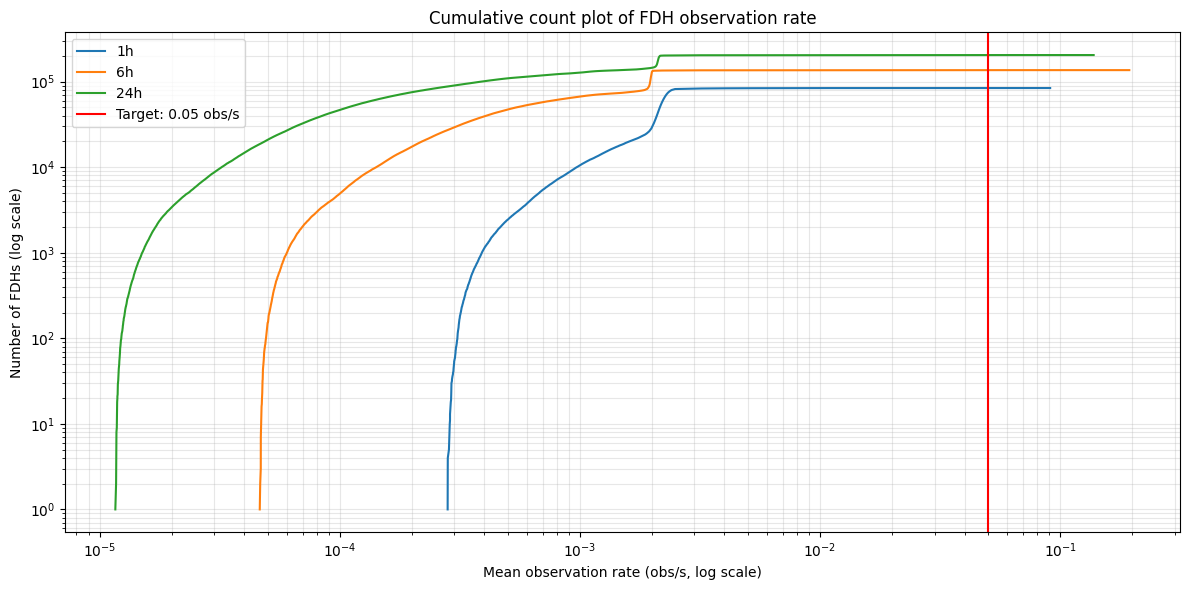

In [31]:

# --- Summary table ---
rows = "\n".join(
    f"| `{label}` | `{len(d):,}` | `{d['rate'].mean():.4f}` "
    f"| `{d['rate'].median():.4f}` "
    f"| `{100 * (d['rate'] >= 1/20).mean():.5f}%` |"
    for label, d in cadence_data.items()
)
display(Markdown(f"""
| Dataset | FDHs with rate estimate | Mean rate (obs/s) | Median rate (obs/s) | % at or above target (≥ 0.05 obs/s) |
|---------|------------------------|-------------------|---------------------|--------------------------------------|
{rows}
"""))

# --- Plot ---
cmap = plt.get_cmap('tab10')
colors = {'1h': cmap(0), '6h': cmap(1), '24h': cmap(2)}

fig, ax = plt.subplots(figsize=(12, 6))
for label, d in cadence_data.items():
    sorted_rate = d['rate'].sort_values()
    ax.plot(sorted_rate.values, range(1, len(sorted_rate) + 1),
            label=label, color=colors[label])

ax.axvline(1/20, color='red', linestyle='-', linewidth=1.5, label='Target: 0.05 obs/s')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Mean observation rate (obs/s, log scale)')
ax.set_ylabel('Number of FDHs (log scale)')
ax.set_title('Cumulative count plot of FDH observation rate')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [32]:
display(Markdown("""
### Observations

The cumulative observation rate plot reveals a clear and expected pattern across the three
streaming horizons:

- **The curves shift left as the streaming horizon shrinks.** The 1h curve is concentrated
  around $10^{-3}$ obs/s, the 6h curve around $10^{-4}$ obs/s, and the 24h curve around
  $10^{-5}$ obs/s. This is a direct artifact of the streaming duration: an FDH observed
  twice in 1 hour has a much higher rate than one observed twice over 24 hours.

- **Virtually no FDHs meet the target refresh cadence of 0.05 obs/s** (red line) in any
  of the three datasets. The bulk of the mass in all three curves sits 1–2 orders of
  magnitude below the target, suggesting that in practice Retina is refreshing most FDHs
  far less frequently than the proposed $\\tau_{FDH} = 20s$.

- **The sharp vertical rise** visible in each curve corresponds to FDHs observed exactly
  twice — they all share the same rate of `1 / stream_duration`, creating a discrete
  spike. FDHs observed more frequently form the gradual tail to the right.

- **The 24h dataset has the most FDHs with a cadence estimate**, as expected from the
  longer streaming window giving more opportunities for repeat observations.
"""))


### Observations

The cumulative observation rate plot reveals a clear and expected pattern across the three
streaming horizons:

- **The curves shift left as the streaming horizon shrinks.** The 1h curve is concentrated
  around $10^{-3}$ obs/s, the 6h curve around $10^{-4}$ obs/s, and the 24h curve around
  $10^{-5}$ obs/s. This is a direct artifact of the streaming duration: an FDH observed
  twice in 1 hour has a much higher rate than one observed twice over 24 hours.

- **Virtually no FDHs meet the target refresh cadence of 0.05 obs/s** (red line) in any
  of the three datasets. The bulk of the mass in all three curves sits 1–2 orders of
  magnitude below the target, suggesting that in practice Retina is refreshing most FDHs
  far less frequently than the proposed $\tau_{FDH} = 20s$.

- **The sharp vertical rise** visible in each curve corresponds to FDHs observed exactly
  twice — they all share the same rate of `1 / stream_duration`, creating a discrete
  spike. FDHs observed more frequently form the gradual tail to the right.

- **The 24h dataset has the most FDHs with a cadence estimate**, as expected from the
  longer streaming window giving more opportunities for repeat observations.


In [ ]:
display(Markdown("""
## Question 5: PD-to-FDH Mapping — Evolution Over Time
Here we investigate how $k_H$ evolves as the streaming horizon extends from 1h to 24h
using cumulative slices of the 24h dataset.
"""))

df_kh_raw = pd.read_sql_query("""
    SELECT
        agent_id,
        near_reply_address,
        destination_address,
        near_probe_ttl,
        production_timestamp
    FROM fies
    WHERE near_reply_address IS NOT NULL AND near_reply_address != ''
""", con24h)

df_kh_raw['production_timestamp'] = pd.to_datetime(df_kh_raw['production_timestamp'], format='ISO8601')
df_kh_raw['pd_id'] = df_kh_raw['agent_id'] + '|' + df_kh_raw['near_probe_ttl'].astype(str)
t_start = df_kh_raw['production_timestamp'].min()

records = []
for h in range(1, 25):
    cutoff = t_start + pd.Timedelta(hours=h)
    df_slice = df_kh_raw[df_kh_raw['production_timestamp'] < cutoff]
    df_kh = (
        df_slice
        .groupby(['near_reply_address', 'destination_address'])['pd_id']
        .nunique()
        .reset_index()
        .rename(columns={'pd_id': 'k_H'})
    )
    records.append({
        'hour':      h,
        'mean_kH':   df_kh['k_H'].mean(),
        'median_kH': df_kh['k_H'].median(),
        'min_kH':    df_kh['k_H'].min(),
        'max_kH':    df_kh['k_H'].max(),
    })

df_evolution = pd.DataFrame(records)

# --- Table ---
table_rows = "\n".join(
    f"| {int(r.hour)}h | {r.mean_kH:.3f} | {r.median_kH:.0f} | {int(r.min_kH)} | {int(r.max_kH)} |"
    for _, r in df_evolution.iterrows()
)
display(Markdown(f"""
| Hour | Mean $k_H$ | Median $k_H$ | Min $k_H$ | Max $k_H$ |
|------|-----------|--------------|-----------|-----------|
{table_rows}
"""))

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df_evolution['hour'], df_evolution['mean_kH'],   label='Mean',   marker='o', color='steelblue')
axes[0].plot(df_evolution['hour'], df_evolution['median_kH'], label='Median', marker='o', color='darkorange', linestyle='--')
axes[0].set_ylabel('$k_H$')
axes[0].set_title('Mean and Median $k_H$ by Streaming Horizon (24h data)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_evolution['hour'], df_evolution['max_kH'], label='Max', marker='o', color='crimson')
axes[1].plot(df_evolution['hour'], df_evolution['min_kH'], label='Min', marker='o', color='seagreen', linestyle='--')
axes[1].set_ylabel('$k_H$')
axes[1].set_title('Min and Max $k_H$ by Streaming Horizon (24h data)')
axes[1].set_xlabel('Cumulative Streaming Hours')
axes[1].set_xticks(range(1, 25))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 5: PD-to-FDH Mapping — Evolution Over Time
Here we investigate how $k_H$ evolves as the streaming horizon extends from 1h to 24h
using cumulative slices of the 24h dataset.
